# Tech Challenge - Fase 1
## Sistema inteligente de suporte ao diagnóstico médico
### Classificação de câncer de mama com Machine Learning

### 1.1 Introdução

Este projeto tem como objetivo desenvolver uma solução inicial de Inteligência Artificial para apoio ao diagnóstico médico, com foco em classificação de exames a partir de dados estruturados.

A proposta utiliza técnicas de Machine Learning para prever se um caso é benigno ou maligno, servindo como ferramenta de apoio à triagem clínica. Ressalta-se que a decisão final deve sempre permanecer com o profissional de saúde.

### 1.2 Objetivo do Projeto

O objetivo deste trabalho é desenvolver um modelo de Machine Learning capaz de classificar exames médicos em benignos ou malignos, utilizando dados estruturados da base Breast Cancer Wisconsin. A proposta visa apoiar a triagem clínica por meio da análise automatizada dos atributos dos exames, contribuindo para maior agilidade e suporte à tomada de decisão médica.

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### 1.3 Base de Dados

Foi utilizado o dataset Breast Cancer Wisconsin, amplamente empregado em estudos de classificação na área médica. A base contém atributos numéricos extraídos de exames, com o objetivo de classificar os casos em malignos ou benignos.

Neste trabalho, a variável alvo foi representada por:
- 0 = maligno
- 1 = benigno

In [ ]:
# Carregando a base de câncer de mama
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Ajustando nomes do alvo para facilitar a leitura
df['diagnostico'] = df['target'].map({0: 'maligno', 1: 'benigno'})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,maligno


In [ ]:
print("Dimensões da base:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

Dimensões da base: (569, 32)

Colunas:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target', 'diagnostico']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


### 1.4 Verificação de valores ausentes

Foi realizada a análise de valores ausentes na base de dados, e constatou-se que não há registros nulos nas variáveis utilizadas. Isso indica que a base está consistente para a etapa de modelagem, não sendo necessário aplicar técnicas de imputação de dados faltantes.

In [ ]:
df['diagnostico'].value_counts()

,count
diagnostico,
benigno,357
maligno,212


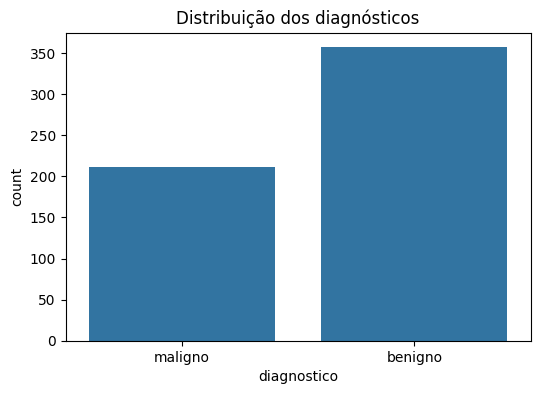

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='diagnostico')
plt.title('Distribuição dos diagnósticos')
plt.show()

# 2. Análise Exploratória dos Dados

Nesta etapa, serão analisadas as características gerais da base, as distribuições das variáveis e a relação entre os atributos, com o objetivo de compreender os dados antes da modelagem.

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
df['diagnostico'].value_counts(normalize=True) * 100

,proportion
diagnostico,
benigno,62.741652
maligno,37.258348


### 2.1 Distribuição das classes

A base apresenta distribuição relativamente equilibrada entre os diagnósticos benigno e maligno, o que favorece a etapa de modelagem e reduz o risco de viés causado por desbalanceamento severo.

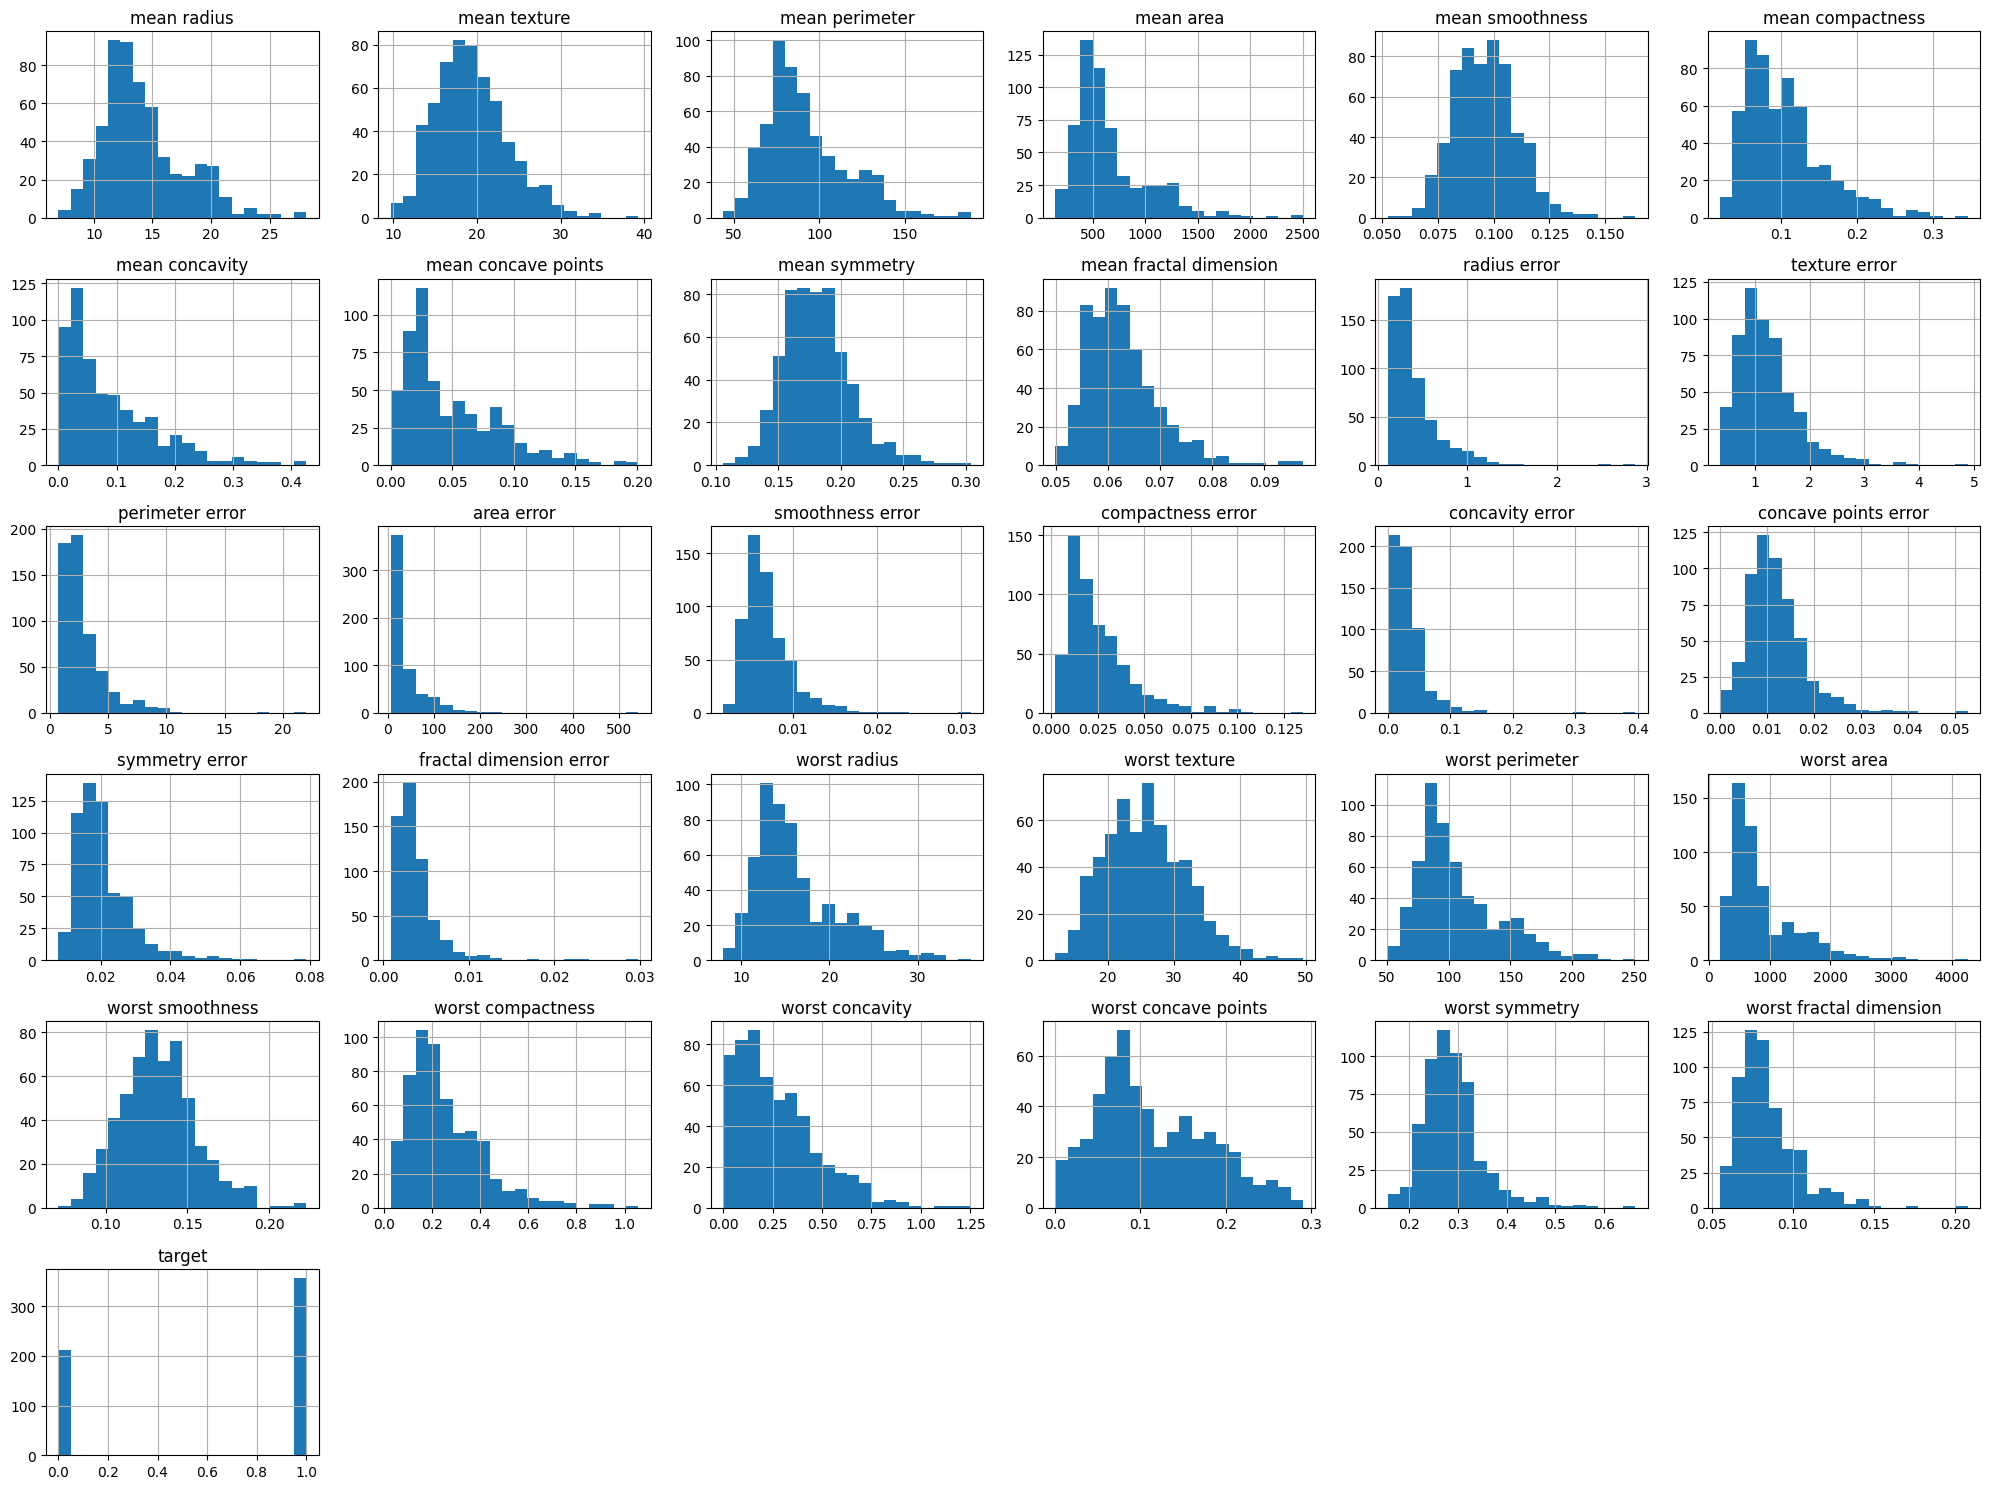

In [ ]:
df.hist(figsize=(20, 15), bins=20)
plt.tight_layout()
plt.show()

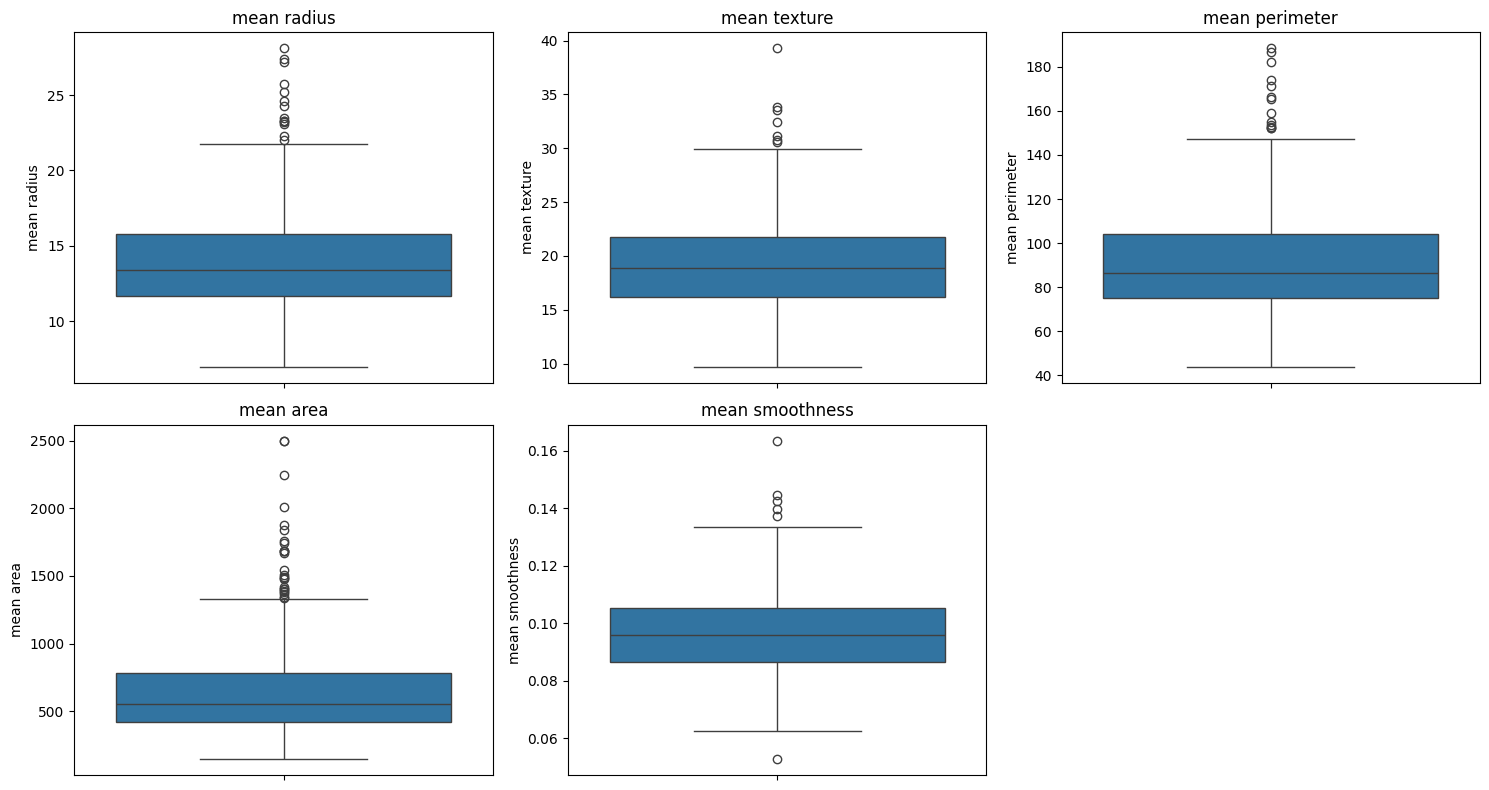

In [ ]:
colunas_boxplot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

plt.figure(figsize=(15,8))
for i, col in enumerate(colunas_boxplot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

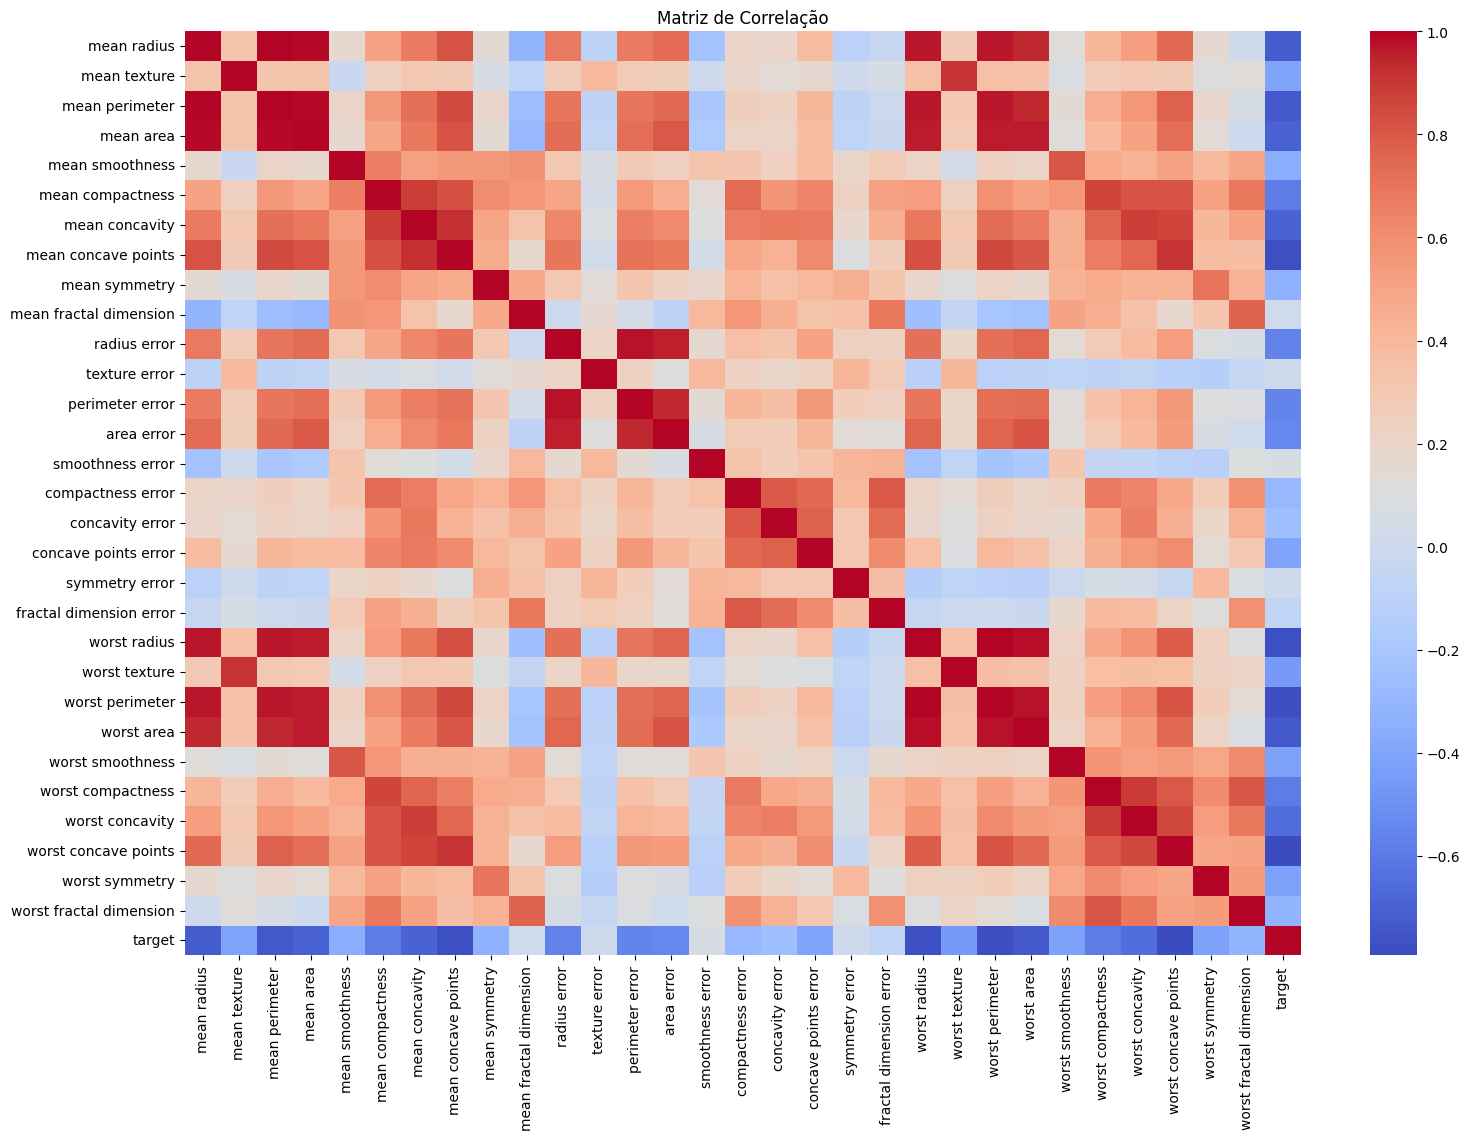

In [ ]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.drop(columns=['diagnostico']).corr(), cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
correlacao_target = df.drop(columns=['diagnostico']).corr()['target'].sort_values(ascending=False)
correlacao_target

,target
target,1.000000
smoothness error,0.067016
mean fractal dimension,0.012838
texture error,0.008303
symmetry error,0.006522
fractal dimension error,-0.077972
concavity error,-0.253730
compactness error,-0.292999
worst fractal dimension,-0.323872
mean symmetry,-0.330499


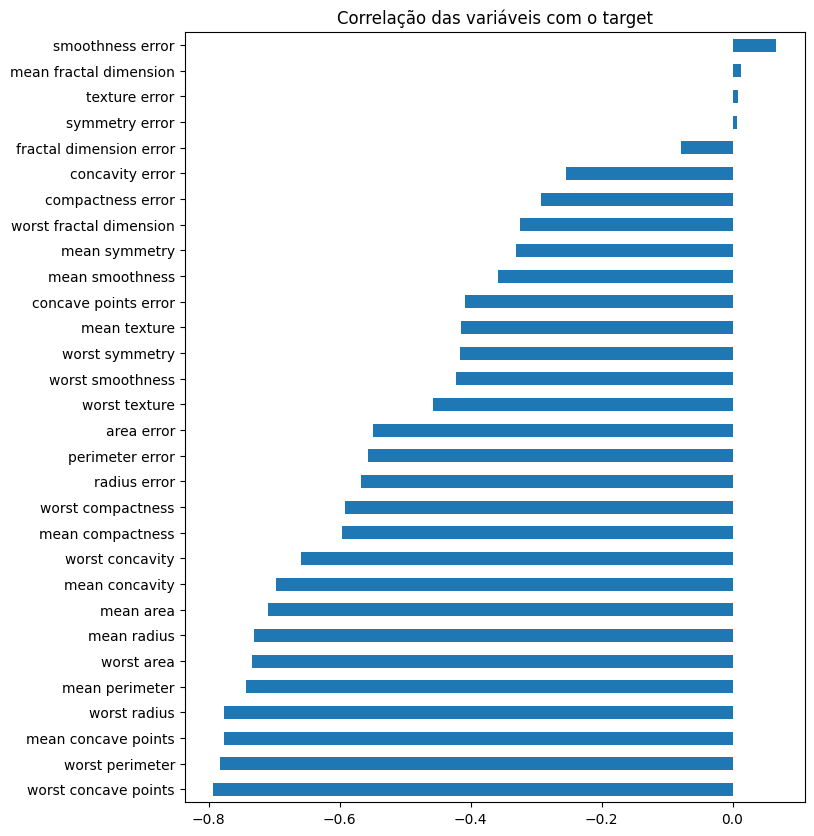

In [ ]:
plt.figure(figsize=(8,10))
correlacao_target.drop('target').sort_values().plot(kind='barh')
plt.title('Correlação das variáveis com o target')
plt.show()

### 2.2 Interpretação da correlação

A matriz de correlação indicou que algumas variáveis apresentam forte associação entre si, sugerindo possível redundância entre atributos. Ainda assim, os dados foram mantidos para a etapa inicial de modelagem, considerando a capacidade dos algoritmos testados em lidar com esse comportamento.

### 2.3 Principais achados da análise exploratória

A análise exploratória permitiu observar a distribuição das variáveis, identificar possíveis outliers e entender a relação entre os atributos da base.

Também foi possível verificar a proporção entre os diagnósticos benigno e maligno, além de analisar a correlação entre as variáveis, o que ajuda a compreender quais atributos podem ter maior influência na predição.

# 3. Pré-processamento dos Dados

Nesta etapa, os dados serão preparados para a modelagem. Será realizada a separação entre variáveis explicativas e variável alvo, além da divisão da base em conjuntos de treino, validação e teste.

In [ ]:
# Variáveis preditoras
X = df.drop(columns=['target', 'diagnostico'])

# Variável alvo
y = df['target']

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (569, 30)
Dimensão de y: (569,)


In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("X_temp:", X_temp.shape)
print("X_test:", X_test.shape)
print("y_temp:", y_temp.shape)
print("y_test:", y_test.shape)

X_temp: (483, 30)
X_test: (86, 30)
y_temp: (483,)
y_test: (86,)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (397, 30)
X_val: (86, 30)
X_test: (86, 30)


### 3.1 Padronização das variáveis

Foi aplicada a padronização dos atributos numéricos para colocar as variáveis em escala comparável, o que é especialmente importante para modelos sensíveis à magnitude dos dados, como Regressão Logística e KNN.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Padronização concluída.")

Padronização concluída.


In [ ]:
print("Treino escalado:", X_train_scaled.shape)
print("Validação escalado:", X_val_scaled.shape)
print("Teste escalado:", X_test_scaled.shape)

Treino escalado: (397, 30)
Validação escalado: (86, 30)
Teste escalado: (86, 30)


### 3.2 Resultado do pré-processamento

Após a separação entre variáveis explicativas e variável alvo, a base foi dividida em conjuntos de treino, validação e teste. Em seguida, foi aplicada a padronização dos atributos, preparando os dados para a etapa de modelagem preditiva.

# 4. Modelagem Preditiva

Nesta etapa, serão treinados modelos de classificação para prever o diagnóstico com base nos atributos da base de dados. Serão utilizados diferentes algoritmos de Machine Learning, permitindo comparar desempenho e capacidade preditiva.# Nova seção

In [ ]:
# Criando os modelos
modelo_log = LogisticRegression(random_state=42, max_iter=1000)
modelo_tree = DecisionTreeClassifier(random_state=42)
modelo_rf = RandomForestClassifier(random_state=42)

# Treinando os modelos
modelo_log.fit(X_train_scaled, y_train)
modelo_tree.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


In [ ]:
# Previsões no conjunto de validação
y_val_pred_log = modelo_log.predict(X_val_scaled)
y_val_pred_tree = modelo_tree.predict(X_val)
y_val_pred_rf = modelo_rf.predict(X_val)

print("Previsões realizadas na validação.")

Previsões realizadas na validação.


In [ ]:
# Função para avaliar modelos
def avaliar_modelo(nome, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Modelo: {nome}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("-" * 30)

avaliar_modelo("Regressão Logística", y_val, y_val_pred_log)
avaliar_modelo("Árvore de Decisão", y_val, y_val_pred_tree)
avaliar_modelo("Random Forest", y_val, y_val_pred_rf)

Modelo: Regressão Logística
Accuracy: 1.0000
Recall:   1.0000
F1-score: 1.0000
------------------------------
Modelo: Árvore de Decisão
Accuracy: 0.9535
Recall:   0.9444
F1-score: 0.9623
------------------------------
Modelo: Random Forest
Accuracy: 0.9651
Recall:   0.9630
F1-score: 0.9720
------------------------------


In [ ]:
resultados_validacao = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_val, y_val_pred_log),
        accuracy_score(y_val, y_val_pred_tree),
        accuracy_score(y_val, y_val_pred_rf)
    ],
    'Recall': [
        recall_score(y_val, y_val_pred_log),
        recall_score(y_val, y_val_pred_tree),
        recall_score(y_val, y_val_pred_rf)
    ],
    'F1-score': [
        f1_score(y_val, y_val_pred_log),
        f1_score(y_val, y_val_pred_tree),
        f1_score(y_val, y_val_pred_rf)
    ]
})

resultados_validacao.sort_values(by='F1-score', ascending=False)

,Modelo,Accuracy,Recall,F1-score
0,Regressão Logística,1.000000,1.000000,1.000000
2,Random Forest,0.965116,0.962963,0.971963
1,Árvore de Decisão,0.953488,0.944444,0.962264


### 4.1 Comparação inicial dos modelos

Foram treinados três algoritmos de classificação: Regressão Logística, Árvore de Decisão e Random Forest. A avaliação inicial foi realizada no conjunto de validação, utilizando as métricas accuracy, recall e F1-score.

A comparação entre os modelos permite identificar qual apresenta melhor equilíbrio entre desempenho geral e capacidade de identificar corretamente os casos positivos, aspecto especialmente importante no contexto médico.

### 4.2 Modelo selecionado: Regressão Logística

Com base nos resultados obtidos no conjunto de validação, o modelo **Regressão Logística** apresentou o melhor desempenho geral e foi selecionado para a avaliação final no conjunto de teste.

In [ ]:
# Previsão final no teste com a Regressão Logística
y_test_pred_log = modelo_log.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_test_pred_log))
print("Recall:", recall_score(y_test, y_test_pred_log))
print("F1-score:", f1_score(y_test, y_test_pred_log))

Accuracy: 0.9651162790697675
Recall: 0.9629629629629629
F1-score: 0.9719626168224299


In [ ]:
print(classification_report(y_test, y_test_pred_log))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95        32
           1       0.98      0.96      0.97        54

    accuracy                           0.97        86
   macro avg       0.96      0.97      0.96        86
weighted avg       0.97      0.97      0.97        86



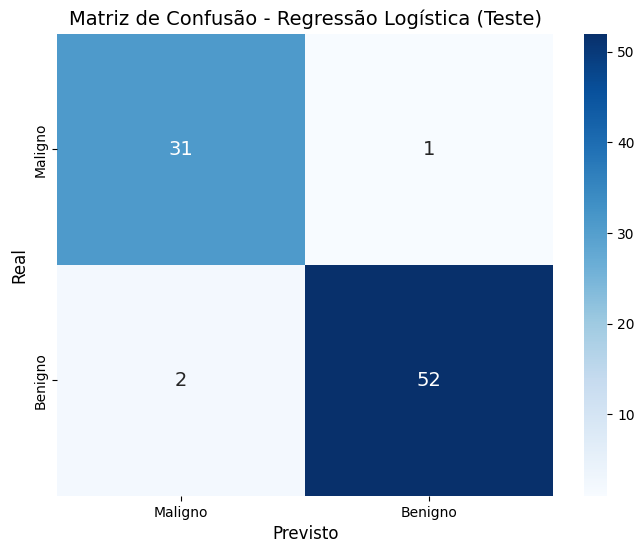

In [ ]:
cm_log = confusion_matrix(y_test, y_test_pred_log)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Maligno', 'Benigno'],
    yticklabels=['Maligno', 'Benigno'],
    annot_kws={"size": 14}
)
plt.title('Matriz de Confusão - Regressão Logística (Teste)', fontsize=14)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.show()

### 4.3 Resultados no conjunto de teste

A Regressão Logística, selecionada com base no melhor desempenho no conjunto de validação, apresentou resultados elevados também no conjunto de teste. O modelo alcançou accuracy de 96,51%, recall de 96,30% e F1-score de 97,20%, indicando forte capacidade de generalização.

A análise do classification report mostrou desempenho consistente nas duas classes, com métricas altas tanto para casos malignos quanto benignos. Além disso, a matriz de confusão evidenciou baixo número de erros de classificação, com apenas 3 previsões incorretas em 86 casos avaliados.

Esses resultados indicam que o modelo conseguiu separar adequadamente as classes da base analisada, mostrando potencial para atuar como ferramenta de apoio à triagem diagnóstica, sempre com supervisão médica.

# 5. Interpretabilidade do Modelo

Nesta etapa, será realizada a interpretação do modelo selecionado, com o objetivo de identificar quais variáveis exerceram maior influência na classificação. Para isso, serão analisados os coeficientes da Regressão Logística e utilizada a técnica SHAP.# Nova seção

In [ ]:
coeficientes = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': modelo_log.coef_[0]
})

coeficientes['Coef_Abs'] = coeficientes['Coeficiente'].abs()

coeficientes.sort_values(by='Coef_Abs', ascending=False).head(10)

,Variavel,Coeficiente,Coef_Abs
28,worst symmetry,-1.102212,1.102212
10,radius error,-1.094417,1.094417
21,worst texture,-1.077301,1.077301
23,worst area,-0.927666,0.927666
13,area error,-0.921105,0.921105
20,worst radius,-0.911261,0.911261
26,worst concavity,-0.884271,0.884271
24,worst smoothness,-0.801235,0.801235
27,worst concave points,-0.780446,0.780446
5,mean compactness,0.734290,0.734290


### 5.1 Interpretação pelos coeficientes

Na Regressão Logística, os coeficientes indicam a direção e a intensidade da influência de cada variável na predição. Coeficientes positivos favorecem a classificação na classe 1, enquanto coeficientes negativos favorecem a classe 0.

Ao analisar os coeficientes em valor absoluto, é possível identificar quais atributos tiveram maior peso na tomada de decisão do modelo.

In [ ]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

X_test_scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.232094,0.919037,0.371963,0.069931,0.585965,1.741933,1.013289,1.035199,-0.246695,0.547522,...,-0.013798,0.350093,0.372652,-0.148001,-0.011787,1.323521,0.913475,0.897658,0.175910,0.199795
1,0.631938,0.334239,0.639306,0.477468,1.488636,0.523121,0.743149,0.935363,0.508601,-0.000283,...,0.655789,0.778866,0.710410,0.456966,1.193613,0.269745,0.441370,0.681650,0.337496,-0.072084
2,0.972231,1.262898,1.017698,0.966913,0.622072,1.046786,1.583175,1.432492,-0.959036,0.121760,...,1.463478,1.100446,1.479414,1.426567,0.252169,0.816767,1.056724,0.888658,-1.141876,0.524856
3,-1.353670,-1.499686,-1.228391,-1.140651,4.846570,2.219501,0.120222,0.106985,2.047831,4.472300,...,-1.227425,-1.529913,-1.121628,-1.019563,2.566185,0.575780,-0.271547,-0.155382,0.235524,2.272262
4,1.562071,2.219626,1.737467,1.603851,-0.266155,1.894976,1.120605,1.691041,0.311723,-0.062691,...,1.863138,1.750202,2.182073,1.905072,-0.165762,1.745403,0.752616,1.218671,-0.109610,0.931860


In [ ]:
explainer = shap.Explainer(modelo_log, X_train_scaled_df)
shap_values = explainer(X_test_scaled_df)

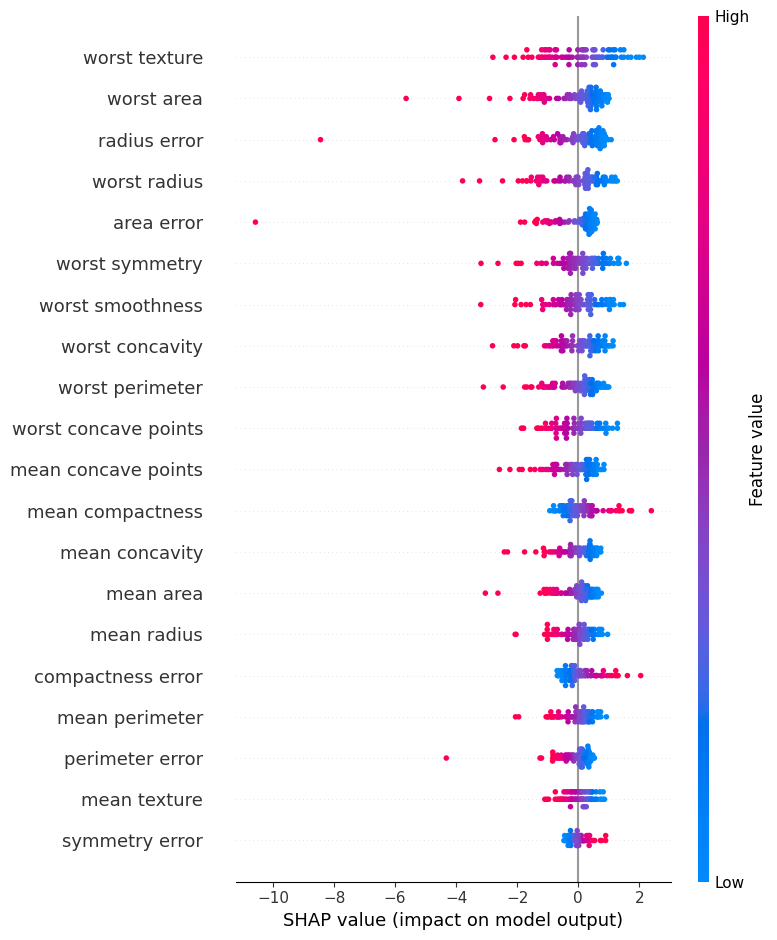

In [ ]:
shap.summary_plot(shap_values, X_test_scaled_df)

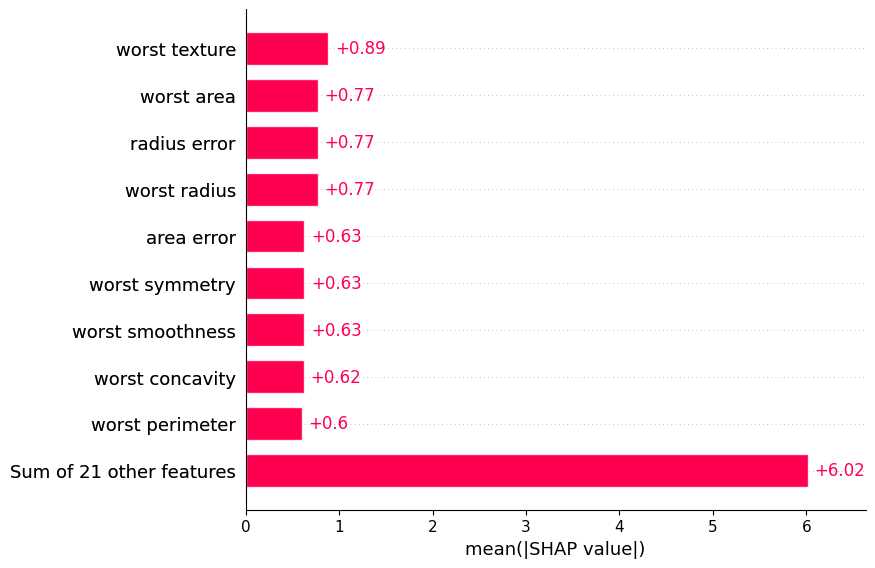

In [ ]:
shap.plots.bar(shap_values)

### 5.2 Feature Importance

Além da análise por coeficientes da Regressão Logística e da técnica SHAP, foi avaliada a importância das variáveis por meio do modelo Random Forest. Essa abordagem permite observar, de forma complementar, quais atributos mais contribuíram para a capacidade preditiva do modelo baseado em árvores.

In [ ]:
rf_importancia = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

rf_importancia.head(10)

,Variavel,Importancia
27,worst concave points,0.144500
23,worst area,0.135319
7,mean concave points,0.098341
20,worst radius,0.096767
0,mean radius,0.068215
22,worst perimeter,0.066089
2,mean perimeter,0.065172
6,mean concavity,0.056723
26,worst concavity,0.046003
3,mean area,0.039990


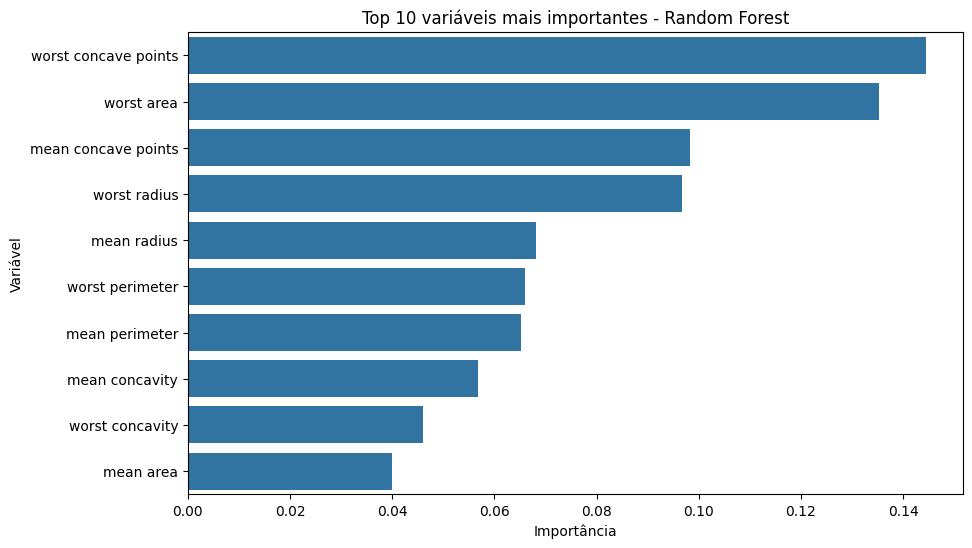

In [ ]:
top_rf = rf_importancia.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_rf, x='Importancia', y='Variavel')
plt.title('Top 10 variáveis mais importantes - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

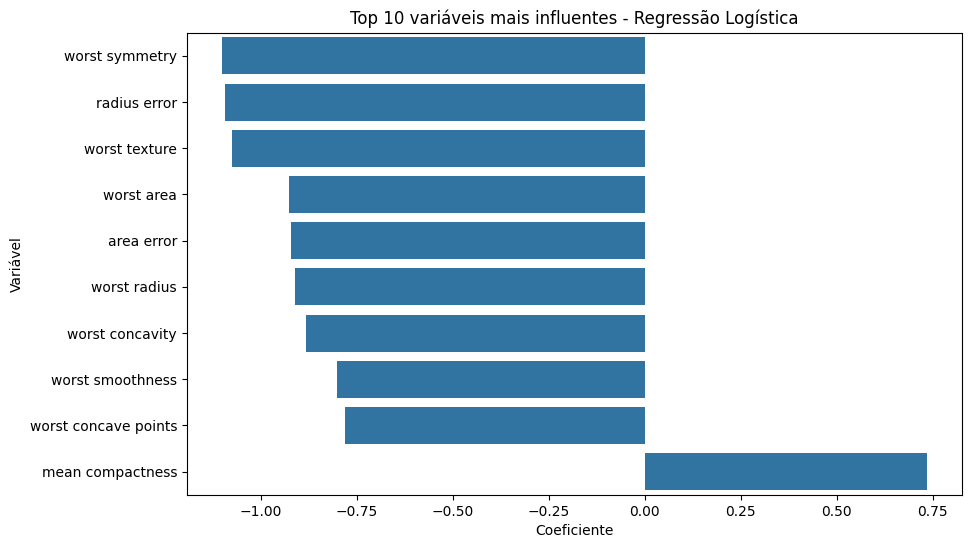

In [ ]:
top_coef = coeficientes.sort_values(by='Coef_Abs', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_coef, x='Coeficiente', y='Variavel')
plt.title('Top 10 variáveis mais influentes - Regressão Logística')
plt.xlabel('Coeficiente')
plt.ylabel('Variável')
plt.show()

### 5.3 Interpretação com SHAP

A técnica SHAP foi utilizada para complementar a interpretabilidade do modelo, permitindo identificar o impacto de cada variável nas predições realizadas. Diferentemente de uma análise apenas global, o SHAP oferece uma visão mais detalhada da contribuição dos atributos, indicando quais características mais influenciam o diagnóstico previsto pelo modelo.

# 6. Conclusão Crítica

Os resultados obtidos mostram que a Regressão Logística apresentou desempenho elevado na classificação dos diagnósticos, com métricas altas tanto no conjunto de validação quanto no conjunto de teste. Isso indica que o modelo foi capaz de generalizar bem para dados não vistos, mantendo baixo número de erros.

A análise de interpretabilidade, por meio dos coeficientes e do SHAP, permitiu identificar as variáveis mais relevantes para a predição, tornando o comportamento do modelo mais transparente. Esse aspecto é especialmente importante em aplicações na área da saúde, nas quais a explicabilidade tem papel central.

Apesar dos resultados promissores, o modelo não deve ser utilizado como substituto da avaliação médica. Seu uso mais adequado é como ferramenta de apoio à triagem e à análise inicial, contribuindo para ganho de eficiência e suporte à tomada de decisão clínica.

Como limitação, destaca-se que o estudo foi realizado com uma base pública e controlada, o que não representa toda a complexidade dos ambientes hospitalares reais. Em aplicações práticas, seria necessário validar o modelo com dados reais, considerar aspectos éticos, privacidade dos pacientes e integração com o fluxo clínico.